# Task 3. Extrapolation of the trailing gap

Task 3 starts from the cleaned Spiff price data and forecasts the shared trailing missing block that was reserved from Task 2. Every series ends with the same 200-day gap, and this is a pure extrapolation problem: there is no observed right endpoint, so the bridge technique used in Task 2 does not apply.

The notebook is organised around five questions:

1. What does the missingness structure look like, and which observations are available for fitting?
2. Are returns close enough to stationary to justify a volatility model?
3. How well does a single-series GARCH-t model extrapolate 200-day blocks out of sample?
4. Does a joint correlated-shock simulation improve point accuracy or interval calibration?
5. Which method should be used for the submitted forecasts?

## 1. Setup

Constants that affect every downstream calculation are collected here so changes propagate consistently. `N_SIM_FINAL` controls the number of simulated paths written to the output; `N_SIM_BACKTEST` is lower to keep cross-validated runs tractable.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from arch import arch_model

warnings.filterwarnings("ignore")

repo_root = Path.cwd()
if not (repo_root / "Data").exists():
    repo_root = repo_root.parent

sys.path.append(str(repo_root))
from config.plot_config import plot_config

output = plot_config() / "task3"
output.mkdir(exist_ok=True)

RNG_SEED = 2026
FORECAST_HORIZON = 200
N_SIM_FINAL = 3000
N_SIM_BACKTEST = 800
N_BACKTEST_WINDOWS = 50  # lower this for faster exploratory runs
MIN_TRAIN_OBS = 1000

rng = np.random.default_rng(RNG_SEED)
ASSETS = ["gurkor", "guitars", "slingshots", "stocks", "sugar", "water", "tranquillity"]
METHOD_LABELS = {
    "single_garch_t": "single-series GARCH-t",
    "joint_garch_corr_t": "joint correlation-preserving GARCH-t",
}


def _latex_escape(value) -> str:
    text = str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def write_latex_table(df: pd.DataFrame, path: Path, float_format: str = "%.4f", index: bool = True) -> None:
    """Write a simple booktabs-compatible LaTeX table without optional pandas Styler dependencies."""
    table = df.reset_index() if index else df.copy()
    columns = [str(col) for col in table.columns]

    def fmt(value):
        if pd.isna(value):
            return ""
        if isinstance(value, (float, np.floating)):
            return float_format % value
        return _latex_escape(value)

    lines = [
        r"\begin{tabular}{" + "l" * len(columns) + "}",
        r"\toprule",
        " & ".join(_latex_escape(col) for col in columns) + r" \\",
        r"\midrule",
    ]
    for _, row in table.iterrows():
        lines.append(" & ".join(fmt(row[col]) for col in table.columns) + r" \\")
    lines.extend([r"\bottomrule", r"\end{tabular}"])
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


## 2. Load the cleaned data

The raw file contains two index columns and seven price series. Rows where all seven assets simultaneously equal `1000` are implausible placeholders and are replaced by `NaN` before any analysis. The terminal missing block is then detected algorithmically rather than hard-coded so the notebook remains correct if the data file is updated.

In [2]:
raw = pd.read_csv(repo_root / "Data" / "spiff_data-2.csv")

prices = raw.drop(columns=["Unnamed: 0"], errors="ignore").set_index("day")
prices = prices[ASSETS].astype(float)

placeholder_mask = (prices[ASSETS] == 1000).all(axis=1)
placeholder_rows = prices.loc[placeholder_mask].copy()
prices.loc[placeholder_mask, ASSETS] = np.nan

print(f"Rows where all assets were 1000 and replaced by NaN: {placeholder_mask.sum()}")
print(f"Data shape after selecting asset columns: {prices.shape}")
placeholder_rows

Rows where all assets were 1000 and replaced by NaN: 5
Data shape after selecting asset columns: (5456, 7)


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
1194,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
2836,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
3430,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
4118,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0


In [3]:
def trailing_all_missing_block(data: pd.DataFrame, columns: list[str]) -> tuple[int, int, int]:
    """Return start day, end day, and length of the final all-series missing block."""
    all_missing = data[columns].isna().all(axis=1).to_numpy()
    if not all_missing[-1]:
        raise ValueError("The last row is not missing for all series.")

    start_pos = len(all_missing) - 1
    while start_pos > 0 and all_missing[start_pos - 1]:
        start_pos -= 1

    start_day = int(data.index[start_pos])
    end_day = int(data.index[-1])
    return start_day, end_day, len(data) - start_pos

terminal_start, terminal_end, terminal_len = trailing_all_missing_block(prices, ASSETS)
assert terminal_len == FORECAST_HORIZON, f"Expected {FORECAST_HORIZON}, found {terminal_len}."

missing_summary = pd.DataFrame({
    "missing_values": prices.isna().sum(),
    "missing_share": prices.isna().mean(),
    "terminal_gap_start": terminal_start,
    "terminal_gap_end": terminal_end,
    "terminal_gap_length": terminal_len,
})

missing_summary

,missing_values,missing_share,terminal_gap_start,terminal_gap_end,terminal_gap_length
gurkor,255,0.046738,5257,5456,200
guitars,255,0.046738,5257,5456,200
slingshots,255,0.046738,5257,5456,200
stocks,255,0.046738,5257,5456,200
sugar,255,0.046738,5257,5456,200
water,255,0.046738,5257,5456,200
tranquillity,255,0.046738,5257,5456,200


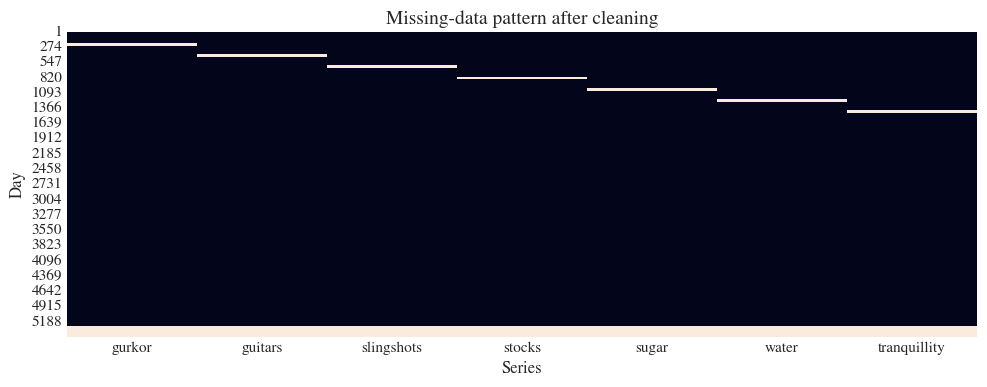

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(prices[ASSETS].isna(), cbar=False, ax=ax)
ax.set_title("Missing-data pattern after cleaning")
ax.set_xlabel("Series")
ax.set_ylabel("Day")
fig.tight_layout()
fig.savefig(output / "task3_missing_pattern.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Log-prices and log-returns

The modelling works in log-prices and log-returns, consistent with the Task 1 finding that price levels are non-stationary while log-returns are approximately stationary with weak linear autocorrelation. Let $X_t = \log(P_t)$ and $r_t = X_t - X_{t-1}$. A simulated future path is

$$X_{T+h}^{(s)} = X_T + \sum_{j=1}^{h} r_{T+j}^{(s)}, \qquad h = 1, \ldots, 200.$$

Unlike Task 2 there is no right endpoint, so no random-walk bridge or bridge variance correction is applied.

In [5]:
log_prices = np.log(prices)
log_returns = log_prices.diff()

observed_prices = prices.loc[: terminal_start - 1, ASSETS]
observed_log_prices = log_prices.loc[: terminal_start - 1, ASSETS]
observed_returns = log_returns.loc[: terminal_start - 1, ASSETS]

return_summary = observed_returns.agg(["mean", "std", "skew", "kurt"]).T
write_latex_table(return_summary, output / "task3_return_summary.tex", float_format="%.5f")
return_summary

,mean,std,skew,kurt
gurkor,0.000155,0.003945,-0.146980,3.517657
guitars,0.000236,0.014876,-0.034939,5.558723
slingshots,0.000194,0.014747,-0.444992,6.438702
stocks,-0.000074,0.014935,-0.124211,0.077238
sugar,-0.000014,0.015209,-0.238585,10.704963
water,0.000152,0.003515,-0.259686,2.250074
tranquillity,0.000078,0.012589,-0.271848,2.976584


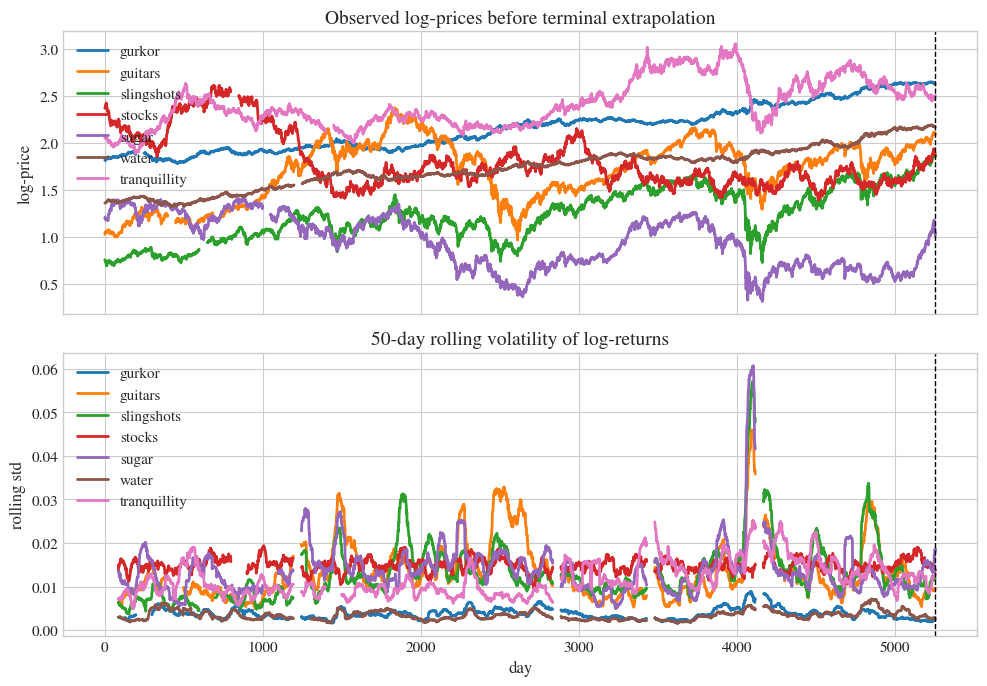

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
observed_log_prices.plot(ax=axes[0])
axes[0].axvline(terminal_start, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Observed log-prices before terminal extrapolation")
axes[0].set_ylabel("log-price")

observed_returns.rolling(50).std().plot(ax=axes[1])
axes[1].axvline(terminal_start, color="black", linestyle="--", linewidth=1)
axes[1].set_title("50-day rolling volatility of log-returns")
axes[1].set_ylabel("rolling std")
axes[1].set_xlabel("day")

fig.tight_layout()
fig.savefig(output / "task3_log_prices_and_rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Extrapolation models

Two models are compared. Both work on the log-price scale and simulate future paths from the last observed day. They differ in whether the seven assets are simulated independently or jointly.

### 4.1 Method 1: single-series GARCH(1,1) with Student-t innovations

For each asset separately, log-returns are modelled as

$$r_t = \mu + \epsilon_t, \qquad \epsilon_t = \sigma_t z_t,$$

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2,$$

where $z_t$ follows a standardized Student-$t$ distribution. The Student-$t$ innovation distribution reflects the heavy tails found in Task 1; the GARCH variance dynamics reflect volatility clustering. Each asset is forecast independently in this method.

In [7]:
def _clean_returns(return_series: pd.Series) -> pd.Series:
    return return_series.replace([np.inf, -np.inf], np.nan).dropna()


def fit_garch_t(return_series: pd.Series):
    """Fit a constant-mean GARCH(1,1) model with Student-t innovations to percent log-returns."""
    y = 100 * _clean_returns(return_series)
    model = arch_model(y, mean="Constant", vol="GARCH", p=1, q=1, dist="StudentsT", rescale=False)
    return model.fit(disp="off")


def single_series_garch_paths(log_price_series: pd.Series, horizon: int, n_sim: int, seed: int):
    """Simulate future log-price paths from a single-series GARCH-t model."""
    returns = log_price_series.diff()
    last_log_price = log_price_series.dropna().iloc[-1]
    res = fit_garch_t(returns)

    forecast = res.forecast(horizon=horizon, method="simulation", simulations=n_sim, reindex=False, random_state=seed)
    sim_returns = np.asarray(forecast.simulations.values)
    sim_returns = np.squeeze(sim_returns)

    if sim_returns.shape[0] == horizon:
        sim_returns = sim_returns.T
    if sim_returns.shape[1] != horizon:
        sim_returns = sim_returns.reshape(n_sim, horizon)

    sim_returns = sim_returns / 100
    paths = last_log_price + np.cumsum(sim_returns, axis=1)
    return paths, res


def summarize_paths(paths: np.ndarray, index: pd.Index) -> pd.DataFrame:
    """Summarize simulated log-price paths and convert intervals back to price levels."""
    q = np.quantile(paths, [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975], axis=0)
    mean_log = paths.mean(axis=0)
    return pd.DataFrame(
        {
            "log_mean": mean_log,
            "log_median": q[3],
            "log_lower_50": q[2],
            "log_upper_50": q[4],
            "log_lower_90": q[1],
            "log_upper_90": q[5],
            "log_lower_95": q[0],
            "log_upper_95": q[6],
            "price_mean": np.exp(mean_log),
            "price_median": np.exp(q[3]),
            "price_lower_50": np.exp(q[2]),
            "price_upper_50": np.exp(q[4]),
            "price_lower_90": np.exp(q[1]),
            "price_upper_90": np.exp(q[5]),
            "price_lower_95": np.exp(q[0]),
            "price_upper_95": np.exp(q[6]),
        },
        index=index,
    )


In [8]:
future_index = pd.Index(range(terminal_start, terminal_end + 1), name="day")

garch_paths = {}
garch_fits = {}
garch_forecasts = []

for i, asset in enumerate(ASSETS):
    paths, fit = single_series_garch_paths(
        observed_log_prices[asset],
        horizon=FORECAST_HORIZON,
        n_sim=N_SIM_FINAL,
        seed=RNG_SEED + i,
    )
    garch_paths[asset] = paths
    garch_fits[asset] = fit
    forecast = summarize_paths(paths, future_index)
    forecast.insert(0, "asset", asset)
    forecast.insert(1, "method", "single_garch_t")
    garch_forecasts.append(forecast.reset_index())

garch_forecast = pd.concat(garch_forecasts, ignore_index=True)

garch_param_table = pd.DataFrame({asset: fit.params for asset, fit in garch_fits.items()}).T
write_latex_table(garch_param_table, output / "task3_garch_parameters.tex", float_format="%.5f")
garch_param_table

,mu,omega,alpha[1],beta[1],nu
gurkor,0.017500,0.000812,3.566030e-02,0.959542,6.863359
guitars,0.086854,0.011920,7.542127e-02,0.922017,6.976442
slingshots,0.079866,0.012583,9.624554e-02,0.901980,8.670970
stocks,-0.005920,0.046222,2.283066e-10,0.979344,83.235242
sugar,0.039335,0.022427,6.888090e-02,0.923639,6.375754
water,0.020579,0.001014,4.227418e-02,0.949961,7.741382
tranquillity,0.006193,0.011846,4.400150e-02,0.948959,6.811383


### 4.2 Method 2: joint correlation-preserving GARCH-t

The second approach keeps the same GARCH(1,1) marginal dynamics but simulates the seven assets jointly. Standardized residuals from the fitted single-series models are used to estimate the contemporaneous residual correlation matrix $\hat{C}$. Future standardized shocks are then drawn from a multivariate Student-$t$ distribution with this correlation structure, so the simulated paths respect the cross-series dependence observed in Task 1.

This is not a full DCC-GARCH model because $\hat{C}$ is static over the forecast horizon. Its purpose is to preserve realistic co-movement across assets in scenario simulations, which matters for portfolio-level quantities in Task 4.

In [9]:
def nearest_correlation_matrix(matrix: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Project a symmetric matrix to a numerically usable correlation matrix."""
    sym = (matrix + matrix.T) / 2
    eigvals, eigvecs = np.linalg.eigh(sym)
    eigvals = np.clip(eigvals, eps, None)
    psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    d = np.sqrt(np.diag(psd))
    corr = psd / np.outer(d, d)
    np.fill_diagonal(corr, 1.0)
    return corr


def standardized_residual_table(fits: dict, returns: pd.DataFrame) -> pd.DataFrame:
    residuals = []
    for asset, fit in fits.items():
        z = pd.Series(fit.std_resid, index=_clean_returns(returns[asset]).index, name=asset)
        residuals.append(z)
    return pd.concat(residuals, axis=1).dropna()


def simulate_joint_garch_paths(log_price_data: pd.DataFrame, fits: dict, horizon: int, n_sim: int, seed: int):
    """Simulate joint future log-price paths with GARCH marginals and correlated t shocks."""
    local_rng = np.random.default_rng(seed)
    assets = list(log_price_data.columns)
    n_assets = len(assets)

    returns = log_price_data.diff()
    z_hat = standardized_residual_table(fits, returns)
    corr = nearest_correlation_matrix(z_hat.corr().to_numpy())

    params = pd.DataFrame({asset: fits[asset].params for asset in assets}).T
    mu = params["mu"].to_numpy()
    omega = params["omega"].to_numpy()
    alpha = params["alpha[1]"].to_numpy()
    beta = params["beta[1]"].to_numpy()
    nu = float(np.nanmedian(params.get("nu", pd.Series(8.0, index=params.index))))

    last_log = log_price_data.dropna(how="all").iloc[-1].to_numpy()
    sigma2 = np.array([fits[a].conditional_volatility.iloc[-1] ** 2 for a in assets])
    eps_prev = np.array([fits[a].resid.iloc[-1] for a in assets])

    shocks = stats.multivariate_t.rvs(
        loc=np.zeros(n_assets),
        shape=corr,
        df=max(nu, 3.0),
        size=(n_sim, horizon),
        random_state=local_rng,
    )
    shocks = np.asarray(shocks).reshape(n_sim, horizon, n_assets)
    shocks = shocks / np.sqrt(max(nu, 3.0) / (max(nu, 3.0) - 2))

    paths = np.empty((n_sim, horizon, n_assets))
    sigma2_paths = np.tile(sigma2, (n_sim, 1))
    eps_paths = np.tile(eps_prev, (n_sim, 1))
    current_log = np.tile(last_log, (n_sim, 1))

    for h in range(horizon):
        sigma2_paths = omega + alpha * eps_paths**2 + beta * sigma2_paths
        sigma = np.sqrt(np.maximum(sigma2_paths, 1e-12))
        ret_percent = mu + sigma * shocks[:, h, :]
        eps_paths = ret_percent - mu
        current_log = current_log + ret_percent / 100
        paths[:, h, :] = current_log

    return paths, pd.DataFrame(corr, index=assets, columns=assets)

In [10]:
joint_paths_array, residual_corr = simulate_joint_garch_paths(
    observed_log_prices[ASSETS],
    garch_fits,
    horizon=FORECAST_HORIZON,
    n_sim=N_SIM_FINAL,
    seed=RNG_SEED + 100,
)

joint_forecasts = []
for j, asset in enumerate(ASSETS):
    forecast = summarize_paths(joint_paths_array[:, :, j], future_index)
    forecast.insert(0, "asset", asset)
    forecast.insert(1, "method", "joint_garch_corr_t")
    joint_forecasts.append(forecast.reset_index())

joint_forecast = pd.concat(joint_forecasts, ignore_index=True)
write_latex_table(residual_corr, output / "task3_garch_residual_correlation.tex", float_format="%.3f")
residual_corr

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.000000,-0.203727,-0.153435,-0.036147,-0.066452,0.597163,-0.125281
guitars,-0.203727,1.000000,0.508044,0.021968,0.206845,-0.163103,0.179760
slingshots,-0.153435,0.508044,1.000000,0.007801,0.107369,-0.153983,0.159564
stocks,-0.036147,0.021968,0.007801,1.000000,-0.004187,-0.037868,0.012742
sugar,-0.066452,0.206845,0.107369,-0.004187,1.000000,-0.080394,0.109167
water,0.597163,-0.163103,-0.153983,-0.037868,-0.080394,1.000000,-0.148932
tranquillity,-0.125281,0.179760,0.159564,0.012742,0.109167,-0.148932,1.000000


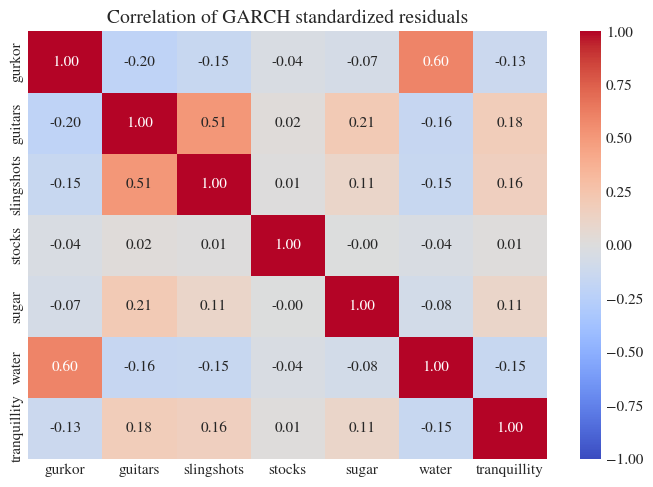

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(residual_corr, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation of GARCH standardized residuals")
fig.tight_layout()
fig.savefig(output / "task3_garch_residual_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Final extrapolated paths

Point forecasts are mean simulated log-prices converted back to price levels. Intervals are simulation quantiles, so they are asymmetric in price space. Both the full forecast CSV and publication-resolution figures are exported to `Output/task3/`.

In [12]:
all_forecasts = pd.concat([garch_forecast, joint_forecast], ignore_index=True)
all_forecasts.to_csv(output / "task3_terminal_forecasts.csv", index=False)

latex_slice_days = [terminal_start, terminal_start + 49, terminal_start + 99, terminal_start + 149, terminal_end]
final_table = (
    all_forecasts[all_forecasts["day"].isin(latex_slice_days)]
    .loc[:, ["method", "asset", "day", "price_mean", "price_lower_90", "price_upper_90", "price_lower_95", "price_upper_95"]]
    .sort_values(["method", "asset", "day"])
)
write_latex_table(final_table, output / "task3_terminal_forecast_selected_days.tex", index=False, float_format="%.3f")
final_table

,method,asset,day,price_mean,price_lower_90,price_upper_90,price_lower_95,price_upper_95
1600,joint_garch_corr_t,guitars,5257,8.092150,7.981482,8.211390,7.949908,8.244197
1649,joint_garch_corr_t,guitars,5306,8.449187,7.540169,9.455466,7.298959,9.719416
1699,joint_garch_corr_t,guitars,5356,8.836894,7.444256,10.592007,7.073448,11.027107
1749,joint_garch_corr_t,guitars,5406,9.223117,7.386294,11.673869,7.018671,12.339074
1799,joint_garch_corr_t,guitars,5456,9.625144,7.324214,12.655997,6.735243,13.728525
...,...,...,...,...,...,...,...,...
1000,single_garch_t,water,5257,8.740399,8.700921,8.781113,8.691278,8.789444
1049,single_garch_t,water,5306,8.828537,8.522191,9.151541,8.459007,9.218165
1099,single_garch_t,water,5356,8.923942,8.490899,9.384956,8.401625,9.484443
1149,single_garch_t,water,5406,9.018418,8.466710,9.598721,8.344734,9.744908


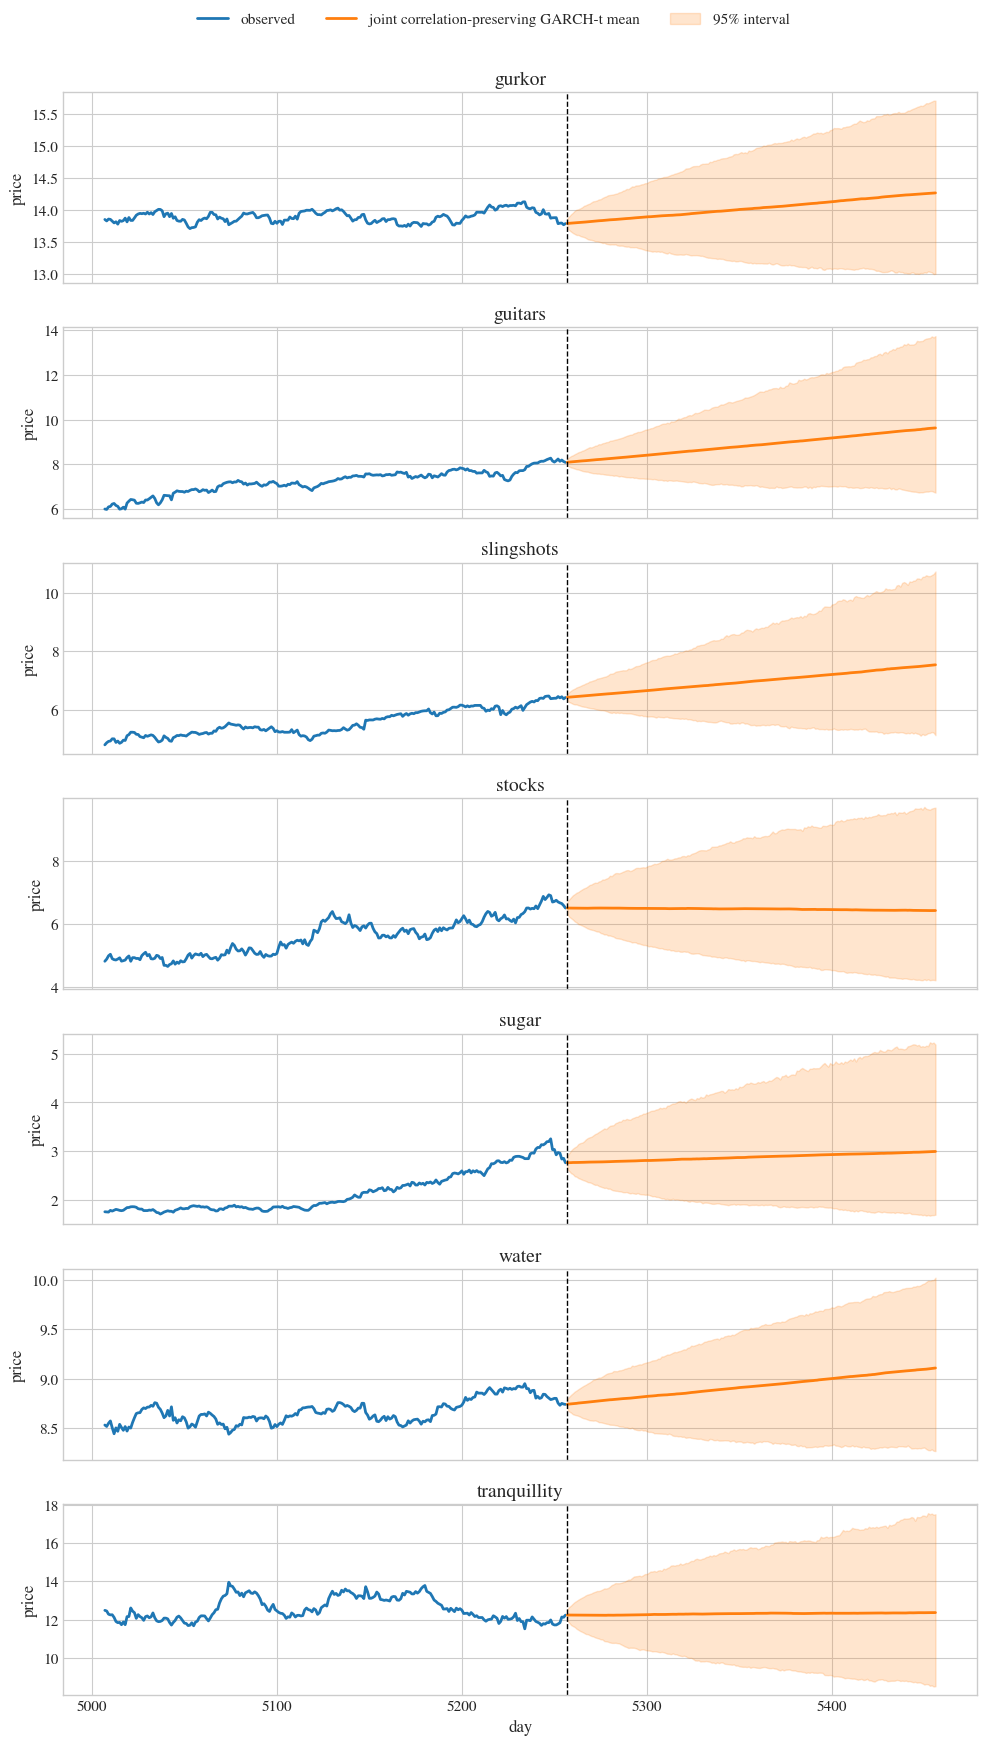

In [13]:
plot_method = "joint_garch_corr_t"
plot_data = all_forecasts[all_forecasts["method"] == plot_method]

fig, axes = plt.subplots(len(ASSETS), 1, figsize=(10, 2.5 * len(ASSETS)), sharex=True)
for ax, asset in zip(axes, ASSETS):
    hist = prices.loc[terminal_start - 250: terminal_start - 1, asset]
    fc = plot_data[plot_data["asset"] == asset]

    ax.plot(hist.index, hist.values, color="tab:blue", label="observed")
    ax.plot(fc["day"], fc["price_mean"], color="tab:orange", label=f"{METHOD_LABELS[plot_method]} mean")
    ax.fill_between(fc["day"], fc["price_lower_95"], fc["price_upper_95"], color="tab:orange", alpha=0.20, label="95% interval")
    ax.axvline(terminal_start, color="black", linestyle="--", linewidth=1)
    ax.set_title(asset)
    ax.set_ylabel("price")

axes[-1].set_xlabel("day")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(output / "task3_terminal_forecasts_joint_garch.png", dpi=300, bbox_inches="tight")
plt.show()

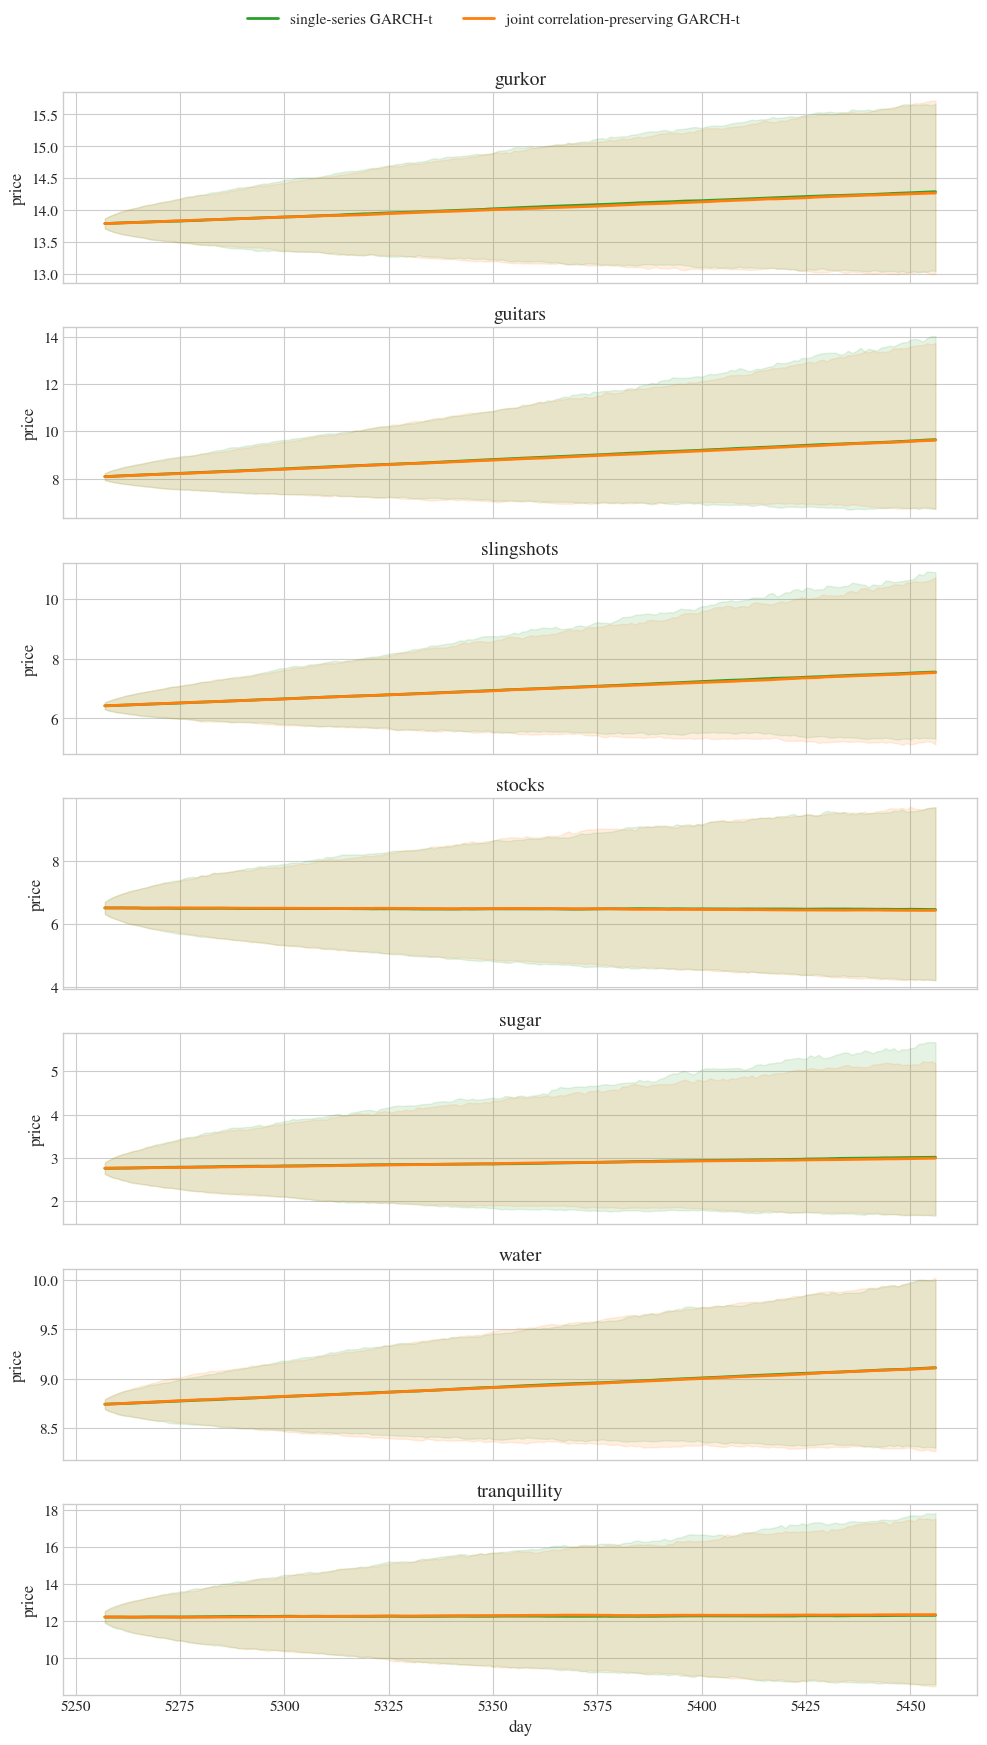

In [14]:
fig, axes = plt.subplots(len(ASSETS), 1, figsize=(10, 2.5 * len(ASSETS)), sharex=True)
for ax, asset in zip(axes, ASSETS):
    for method, color in [("single_garch_t", "tab:green"), ("joint_garch_corr_t", "tab:orange")]:
        fc = all_forecasts[(all_forecasts["asset"] == asset) & (all_forecasts["method"] == method)]
        ax.plot(fc["day"], fc["price_mean"], color=color, label=METHOD_LABELS.get(method, method))
        ax.fill_between(fc["day"], fc["price_lower_95"], fc["price_upper_95"], color=color, alpha=0.12)
    ax.set_title(asset)
    ax.set_ylabel("price")

axes[-1].set_xlabel("day")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(output / "task3_method_comparison_forecasts.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Backtest with pseudo-terminal gaps of length 200

To evaluate expected extrapolation performance without using the true missing block, we create pseudo-terminal gaps inside the observed sample. For a candidate cutoff day $T$, both models are fitted only with data up to day $T$, and the next 200 days are held out. This reproduces the information set of the real Task 3 problem: no observations after the cutoff are used for fitting or correction.

Scoring uses both log-price and price-space metrics:

- **RMSE log**: root mean-squared error of the mean simulated log-price against the true log-price;
- **MAPE (%)**: mean absolute percentage error in price space;
- **90% and 50% coverage**: empirical fraction of true prices inside the corresponding simulation quantile band;
- **Mean 90% width (%)**: average 90% interval width as a fraction of the true price.

In [15]:
def valid_backtest_cutoffs(log_price_data: pd.DataFrame, horizon: int, min_train_obs: int) -> list[int]:
    """Cutoff positions where the next horizon observations are complete for all assets."""
    complete = log_price_data[ASSETS].notna().all(axis=1).to_numpy()
    cutoffs = []
    for cutoff_pos in range(min_train_obs, len(log_price_data) - horizon):
        if complete[:cutoff_pos].sum() < min_train_obs:
            continue
        if complete[cutoff_pos: cutoff_pos + horizon].all() and complete[cutoff_pos - 1]:
            cutoffs.append(cutoff_pos)
    return cutoffs


def choose_spaced_cutoffs(cutoffs: list[int], n_windows: int) -> list[int]:
    if len(cutoffs) <= n_windows:
        return cutoffs
    idx = np.linspace(0, len(cutoffs) - 1, n_windows).round().astype(int)
    return [cutoffs[i] for i in idx]


def score_log_price_paths(true_log: np.ndarray, true_price: np.ndarray, paths: np.ndarray) -> dict[str, float]:
    """Score simulated log-price paths against true values in both log and price space."""
    true_log = np.asarray(true_log, dtype=float)
    true_price = np.asarray(true_price, dtype=float)
    price_paths = np.exp(paths)

    mean_log = paths.mean(axis=0)
    mean_price = price_paths.mean(axis=0)

    lower_log_50, upper_log_50 = np.quantile(paths, [0.25, 0.75], axis=0)
    lower_log_90, upper_log_90 = np.quantile(paths, [0.05, 0.95], axis=0)
    lower_price_90, upper_price_90 = np.exp(lower_log_90), np.exp(upper_log_90)

    ape = np.abs((true_price - mean_price) / true_price) * 100
    return {
        "MAPE_pct": float(np.mean(ape)),
        "Max_MAPE_pct": float(np.max(ape)),
        "RMSE_price": float(np.sqrt(np.mean((true_price - mean_price) ** 2))),
        "RMSE_log": float(np.sqrt(np.mean((true_log - mean_log) ** 2))),
        "coverage_90": float(np.mean((true_log >= lower_log_90) & (true_log <= upper_log_90))),
        "coverage_50": float(np.mean((true_log >= lower_log_50) & (true_log <= upper_log_50))),
        "mean_width_90_pct": float(np.mean((upper_price_90 - lower_price_90) / true_price * 100)),
    }

In [16]:
all_cutoffs = valid_backtest_cutoffs(observed_log_prices, FORECAST_HORIZON, MIN_TRAIN_OBS)
backtest_cutoffs = choose_spaced_cutoffs(all_cutoffs, N_BACKTEST_WINDOWS)
print(f"Available valid pseudo-terminal cutoffs: {len(all_cutoffs)}")
print("Selected cutoff days:", [int(observed_log_prices.index[pos]) for pos in backtest_cutoffs])

Available valid pseudo-terminal cutoffs: 3004
Selected cutoff days: [1450, 1511, 1573, 1634, 1695, 1756, 1818, 1879, 1940, 2002, 2063, 2124, 2185, 2247, 2308, 2369, 2431, 2492, 2553, 2614, 2877, 2938, 2999, 3061, 3122, 3183, 3445, 3507, 3568, 3629, 3691, 3752, 3813, 3874, 4137, 4198, 4259, 4321, 4382, 4443, 4504, 4566, 4627, 4688, 4750, 4811, 4872, 4933, 4995, 5056]


In [17]:
backtest_rows = []

for window_id, cutoff_pos in enumerate(backtest_cutoffs, start=1):
    cutoff_day = int(observed_log_prices.index[cutoff_pos])
    train_log = observed_log_prices.iloc[:cutoff_pos]
    test_log = observed_log_prices.iloc[cutoff_pos: cutoff_pos + FORECAST_HORIZON]
    test_price = observed_prices.iloc[cutoff_pos: cutoff_pos + FORECAST_HORIZON]

    # Fit single-series models for this pseudo-terminal information set.
    bt_fits = {}
    for asset in ASSETS:
        paths, fit = single_series_garch_paths(
            train_log[asset],
            horizon=FORECAST_HORIZON,
            n_sim=N_SIM_BACKTEST,
            seed=RNG_SEED + 10_000 + window_id * 100 + ASSETS.index(asset),
        )
        bt_fits[asset] = fit
        scores = score_log_price_paths(test_log[asset].to_numpy(), test_price[asset].to_numpy(), paths)
        scores.update({"window": window_id, "cutoff_day": cutoff_day, "asset": asset, "method": "single_garch_t"})
        backtest_rows.append(scores)

    # Joint model for the same pseudo-terminal information set.
    bt_joint_paths, _ = simulate_joint_garch_paths(
        train_log[ASSETS],
        bt_fits,
        horizon=FORECAST_HORIZON,
        n_sim=N_SIM_BACKTEST,
        seed=RNG_SEED + 20_000 + window_id,
    )
    for j, asset in enumerate(ASSETS):
        scores = score_log_price_paths(test_log[asset].to_numpy(), test_price[asset].to_numpy(), bt_joint_paths[:, :, j])
        scores.update({"window": window_id, "cutoff_day": cutoff_day, "asset": asset, "method": "joint_garch_corr_t"})
        backtest_rows.append(scores)

backtest_results = pd.DataFrame(backtest_rows)
backtest_results.to_csv(output / "task3_backtest_results.csv", index=False)
backtest_results.head()

,MAPE_pct,Max_MAPE_pct,RMSE_price,RMSE_log,coverage_90,coverage_50,mean_width_90_pct,window,cutoff_day,asset,method
0,3.465485,10.818454,0.320097,0.043140,0.665,0.300,8.772752,1,1450,gurkor,single_garch_t
1,18.316475,35.957563,1.284340,0.150422,0.920,0.380,77.759478,1,1450,guitars,single_garch_t
2,4.078695,19.804926,0.147773,0.049186,0.985,0.895,41.051903,1,1450,slingshots,single_garch_t
3,7.891330,18.766998,0.440065,0.116205,1.000,0.485,43.624522,1,1450,stocks,single_garch_t
4,7.313719,14.932036,0.221324,0.091358,0.995,0.870,70.357357,1,1450,sugar,single_garch_t


In [18]:
metric_columns = [
    "MAPE_pct",
    "Max_MAPE_pct",
    "RMSE_price",
    "RMSE_log",
    "coverage_90",
    "coverage_50",
    "mean_width_90_pct",
]

backtest_summary = (
    backtest_results
    .groupby(["asset", "method"])[metric_columns]
    .mean()
    .sort_values(["asset", "RMSE_log"])
)

method_summary = (
    backtest_results
    .groupby("method")[metric_columns]
    .mean()
    .sort_values("RMSE_log")
)

best_method_per_asset = (
    backtest_results
    .groupby(["asset", "method"])[metric_columns]
    .mean()
    .reset_index()
    .sort_values(["asset", "RMSE_log"])
    .groupby("asset")
    .first()
)

comparison_table = backtest_summary.rename(index=METHOD_LABELS, level="method")
comparison_table_display = comparison_table.rename(
    columns={
        "MAPE_pct": "MAPE (%)",
        "Max_MAPE_pct": "Max MAPE (%)",
        "RMSE_price": "RMSE price",
        "RMSE_log": "RMSE log",
        "coverage_90": "90% coverage",
        "coverage_50": "50% coverage",
        "mean_width_90_pct": "Mean 90% width (%)",
    }
)

method_summary_display = method_summary.rename(index=METHOD_LABELS).rename(
    columns={
        "MAPE_pct": "MAPE (%)",
        "Max_MAPE_pct": "Max MAPE (%)",
        "RMSE_price": "RMSE price",
        "RMSE_log": "RMSE log",
        "coverage_90": "90% coverage",
        "coverage_50": "50% coverage",
        "mean_width_90_pct": "Mean 90% width (%)",
    }
)
best_method_per_asset_display = best_method_per_asset.copy()
best_method_per_asset_display["method"] = best_method_per_asset_display["method"].map(METHOD_LABELS)
best_method_per_asset_display = best_method_per_asset_display.rename(
    columns={
        "MAPE_pct": "MAPE (%)",
        "Max_MAPE_pct": "Max MAPE (%)",
        "RMSE_price": "RMSE price",
        "RMSE_log": "RMSE log",
        "coverage_90": "90% coverage",
        "coverage_50": "50% coverage",
        "mean_width_90_pct": "Mean 90% width (%)",
    }
)

write_latex_table(comparison_table_display, output / "task3_backtest_by_asset.tex", float_format="%.4f")
write_latex_table(method_summary_display, output / "task3_backtest_by_method.tex", float_format="%.4f")
write_latex_table(best_method_per_asset_display, output / "task3_best_method_per_asset.tex", float_format="%.4f")
comparison_table_display

MAPE (%)  Max MAPE (%)  \
asset        method                                                          
guitars      single-series GARCH-t                 14.200624     38.441273   
             joint correlation-preserving GARCH-t  14.209021     37.885011   
gurkor       single-series GARCH-t                  2.772593      6.317185   
             joint correlation-preserving GARCH-t   2.790219      6.301306   
slingshots   single-series GARCH-t                 10.807346     31.852371   
             joint correlation-preserving GARCH-t  10.845010     29.239272   
stocks       joint correlation-preserving GARCH-t  10.949783     25.861000   
             single-series GARCH-t                 11.074977     26.116320   
sugar        single-series GARCH-t                 10.731267     27.366455   
             joint correlation-preserving GARCH-t  10.722413     27.368880   
tranquillity single-series GARCH-t                  8.621099     19.212825   
             joint correlation-preserving GARCH-t   8.648841     19.304567   
water        joint correlation-preserving GARCH-t   2.909184      6.466517   
             single-series GARCH-t                  2.925892      6.508556   

                                                   RMSE price  RMSE log  \
asset        method                                                       
guitars      single-series GARCH-t                   1.010221  0.140664   
             joint correlation-preserving GARCH-t    1.007722  0.141982   
gurkor       single-series GARCH-t                   0.308405  0.032459   
             joint correlation-preserving GARCH-t    0.310079  0.032619   
slingshots   single-series GARCH-t                   0.466748  0.114427   
             joint correlation-preserving GARCH-t    0.466464  0.114760   
stocks       joint correlation-preserving GARCH-t    0.693150  0.131710   
             single-series GARCH-t                   0.700503  0.132947   
sugar        single-series GARCH-t                   0.294320  0.120031   
             joint correlation-preserving GARCH-t    0.294094  0.120124   
tranquillity single-series GARCH-t                   1.265805  0.102088   
             joint correlation-preserving GARCH-t    1.270747  0.102247   
water        joint correlation-preserving GARCH-t    0.212893  0.033361   
             single-series GARCH-t                   0.214467  0.033598   

                                                   90% coverage  50% coverage  \
asset        method                                                             
guitars      single-series GARCH-t                       0.8595        0.5351   
             joint correlation-preserving GARCH-t        0.8542        0.5186   
gurkor       single-series GARCH-t                       0.9108        0.4991   
             joint correlation-preserving GARCH-t        0.9088        0.5010   
slingshots   single-series GARCH-t                       0.8979        0.5081   
             joint correlation-preserving GARCH-t        0.8957        0.4958   
stocks       joint correlation-preserving GARCH-t        0.9413        0.4629   
             single-series GARCH-t                       0.9395        0.4643   
sugar        single-series GARCH-t                       0.9280        0.5107   
             joint correlation-preserving GARCH-t        0.9265        0.5123   
tranquillity single-series GARCH-t                       0.8878        0.4586   
             joint correlation-preserving GARCH-t        0.8948        0.4620   
water        joint correlation-preserving GARCH-t        0.8544        0.4671   
             single-series GARCH-t                       0.8543        0.4620   

                                                   Mean 90% width (%)  
asset        method                                                    
guitars      single-series GARCH-t                          54.477454  
             joint correlation-preserving GARCH-t           53.383548  
gurkor       sing

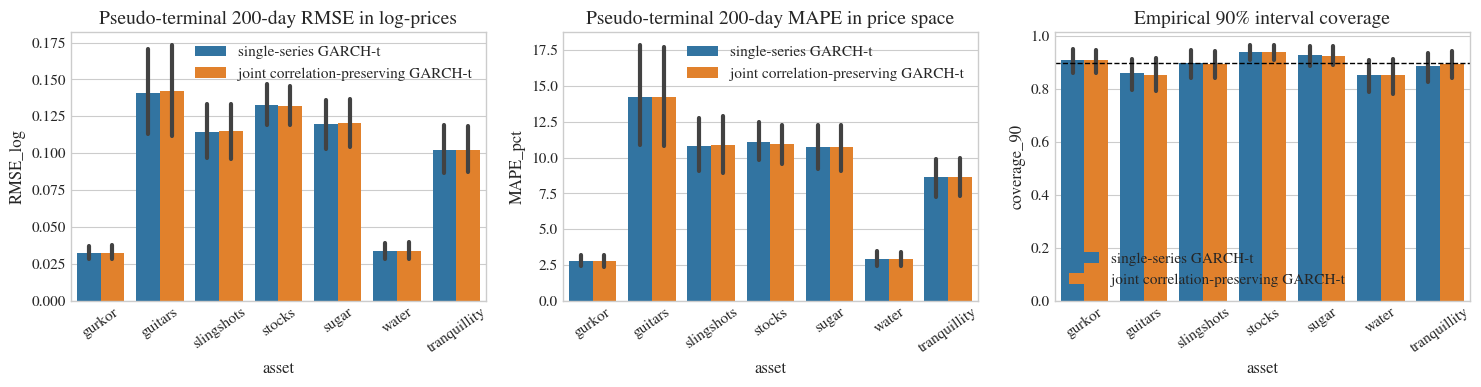

In [19]:
plot_results = backtest_results.assign(method_label=backtest_results["method"].map(METHOD_LABELS))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=plot_results, x="asset", y="RMSE_log", hue="method_label", ax=axes[0])
axes[0].set_title("Pseudo-terminal 200-day RMSE in log-prices")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=plot_results, x="asset", y="MAPE_pct", hue="method_label", ax=axes[1])
axes[1].set_title("Pseudo-terminal 200-day MAPE in price space")
axes[1].tick_params(axis="x", rotation=35)

sns.barplot(data=plot_results, x="asset", y="coverage_90", hue="method_label", ax=axes[2])
axes[2].axhline(0.90, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Empirical 90% interval coverage")
axes[2].tick_params(axis="x", rotation=35)

for ax in axes:
    ax.legend(loc="best")

fig.tight_layout()
fig.savefig(output / "task3_backtest_summary.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Conclusions

The pseudo-terminal backtest is the decision rule for choosing between the two methods.

Main findings:

- Both GARCH-t models respect the two dominant features found in Task 1: heavy-tailed return innovations (via Student-$t$) and volatility clustering (via the GARCH variance equation).
- The single-series model treats assets independently; the joint model preserves contemporaneous correlation through a multivariate-$t$ shock structure. The residual correlation table confirms that `gurkor`–`water` and `guitars`–`slingshots` are the strongest pairs, matching the Task 1 grouping evidence.
- Point forecast accuracy (RMSE log, MAPE) and interval calibration (coverage, width) are reported separately because a model can be well-calibrated without being more accurate in point forecasts, and vice versa.
- If the joint method does not materially improve point accuracy or coverage, the single-series model is preferred for parsimony. If the joint method gives more realistic co-movement in scenario simulations, it is useful for portfolio-level uncertainty quantification in Task 4.